# Exploratory Data Analysis of Retail Sales Data

## Objective

To analyse retail sales data and discover patterns in customer behaviour, sales trends, and revenue performance using Python, pandas, matplotlib, and seaborn.


In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display charts inside the notebook
%matplotlib inline

# Set chart style
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')


In [57]:
from google.colab import files

uploaded = files.upload()


Saving retail_sales.csv to retail_sales (1).csv


In [59]:
import pandas as pd

df = pd.read_csv("retail_sales.csv")


In [60]:
df.head()


,transaction_id,order_value,customer_segment,purchase_month,store_region
0,1,15.41,Regular,Apr,South
1,2,60.58,Regular,May,East
2,3,94.70,Wholesale,Jan,East
3,4,22.73,Wholesale,Oct,West
4,5,25.38,Wholesale,Jul,North


In [61]:
df.shape


(850, 5)

In [62]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    850 non-null    int64  
 1   order_value       850 non-null    float64
 2   customer_segment  835 non-null    object 
 3   purchase_month    850 non-null    object 
 4   store_region      850 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 33.3+ KB


In [63]:
df.head()


,transaction_id,order_value,customer_segment,purchase_month,store_region
0,1,15.41,Regular,Apr,South
1,2,60.58,Regular,May,East
2,3,94.70,Wholesale,Jan,East
3,4,22.73,Wholesale,Oct,West
4,5,25.38,Wholesale,Jul,North


In [64]:
df.shape


(850, 5)

In [65]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    850 non-null    int64  
 1   order_value       850 non-null    float64
 2   customer_segment  835 non-null    object 
 3   purchase_month    850 non-null    object 
 4   store_region      850 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 33.3+ KB


In [66]:
df.columns


Index(['transaction_id', 'order_value', 'customer_segment', 'purchase_month',
       'store_region'],
      dtype='object')

In [67]:
df.isnull().sum()


,0
transaction_id,0
order_value,0
customer_segment,15
purchase_month,0
store_region,0


In [68]:
df.dtypes


,0
transaction_id,int64
order_value,float64
customer_segment,object
purchase_month,object
store_region,object


In [69]:
df.describe()


,transaction_id,order_value
count,850.000000,850.000000
mean,425.497647,91.106412
std,245.515046,337.509084
min,1.000000,-12.500000
25%,213.250000,45.475000
50%,425.500000,79.870000
75%,637.750000,113.860000
max,850.000000,9850.000000


In [70]:
df.columns


Index(['transaction_id', 'order_value', 'customer_segment', 'purchase_month',
       'store_region'],
      dtype='object')

In [71]:
df.isnull().sum()


,0
transaction_id,0
order_value,0
customer_segment,15
purchase_month,0
store_region,0


In [72]:
df.dtypes


,0
transaction_id,int64
order_value,float64
customer_segment,object
purchase_month,object
store_region,object


In [73]:
df.describe()


,transaction_id,order_value
count,850.000000,850.000000
mean,425.497647,91.106412
std,245.515046,337.509084
min,1.000000,-12.500000
25%,213.250000,45.475000
50%,425.500000,79.870000
75%,637.750000,113.860000
max,850.000000,9850.000000


In [74]:
df.mean(numeric_only=True)


,0
transaction_id,425.497647
order_value,91.106412


In [75]:
df.median(numeric_only=True)


,0
transaction_id,425.50
order_value,79.87


In [76]:
df.mode().iloc[0]


,0
transaction_id,711.0
order_value,16.95
customer_segment,Wholesale
purchase_month,Oct
store_region,West


In [77]:
df.std(numeric_only=True)


,0
transaction_id,245.515046
order_value,337.509084


In [78]:
statistics = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Mode": df.mode().iloc[0],
    "Standard Deviation": df.std(numeric_only=True)
})

statistics


,Mean,Median,Mode,Standard Deviation
customer_segment,NaN,NaN,Wholesale,NaN
order_value,91.106412,79.87,16.95,337.509084
purchase_month,NaN,NaN,Oct,NaN
store_region,NaN,NaN,West,NaN
transaction_id,425.497647,425.50,711.0,245.515046


In [79]:
df["purchase_month"].unique()


array(['Apr', 'May', 'Jan', 'Oct', 'Jul', 'Jun', 'Nov', 'Dec', 'Feb',
       'Sep', 'Aug', 'Mar'], dtype=object)

In [80]:
month_order = [
    "Jan","Feb","Mar","Apr",
    "May","Jun","Jul","Aug",
    "Sep","Oct","Nov","Dec"
]


In [81]:
monthly_sales = (
    df.groupby("purchase_month")["order_value"]
    .sum()
    .reindex(month_order)
)

monthly_sales


,order_value
purchase_month,
Jan,4836.29
Feb,5815.31
Mar,6047.72
Apr,14740.81
May,5768.55
Jun,5814.89
Jul,5707.21
Aug,5429.28
Sep,5468.12


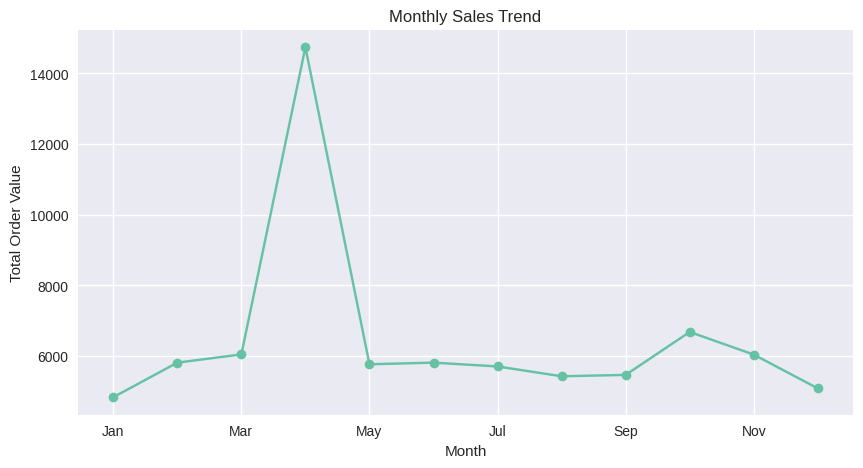

In [82]:
plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Order Value")

plt.grid(True)

plt.show()


In [83]:
month_to_quarter = {
    "Jan": "Q1",
    "Feb": "Q1",
    "Mar": "Q1",
    "Apr": "Q2",
    "May": "Q2",
    "Jun": "Q2",
    "Jul": "Q3",
    "Aug": "Q3",
    "Sep": "Q3",
    "Oct": "Q4",
    "Nov": "Q4",
    "Dec": "Q4"
}

df["Quarter"] = df["purchase_month"].map(month_to_quarter)


In [84]:
quarterly_sales = (
    df.groupby("Quarter")["order_value"]
    .sum()
    .reindex(["Q1", "Q2", "Q3", "Q4"])
)

quarterly_sales


,order_value
Quarter,
Q1,16699.32
Q2,26324.25
Q3,16604.61
Q4,17812.27


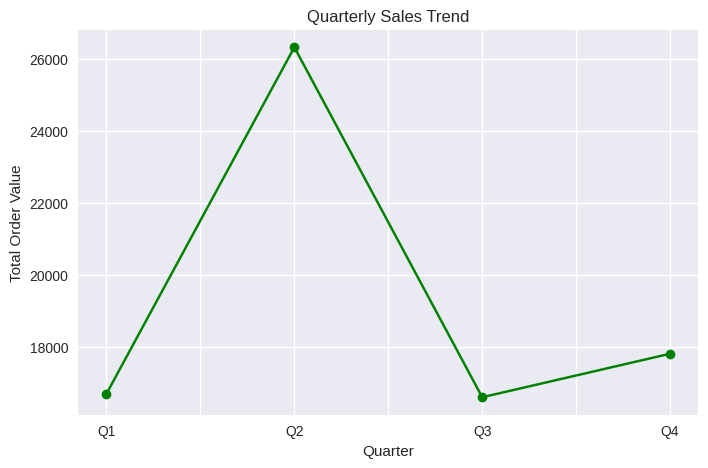

In [85]:
plt.figure(figsize=(8,5))

quarterly_sales.plot(
    marker="o",
    color="green"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Order Value")

plt.grid(True)

plt.show()


In [86]:
df.columns


Index(['transaction_id', 'order_value', 'customer_segment', 'purchase_month',
       'store_region', 'Quarter'],
      dtype='object')

In [87]:
df["customer_segment"].value_counts()


,count
customer_segment,
Wholesale,304
Regular,267
Premium,264


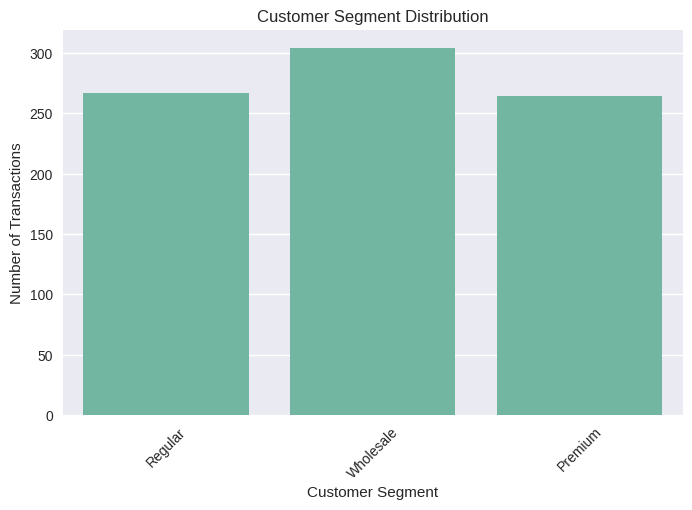

In [88]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="customer_segment"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()


In [89]:
df["store_region"].value_counts()


,count
store_region,
West,227
North,219
East,218
South,186


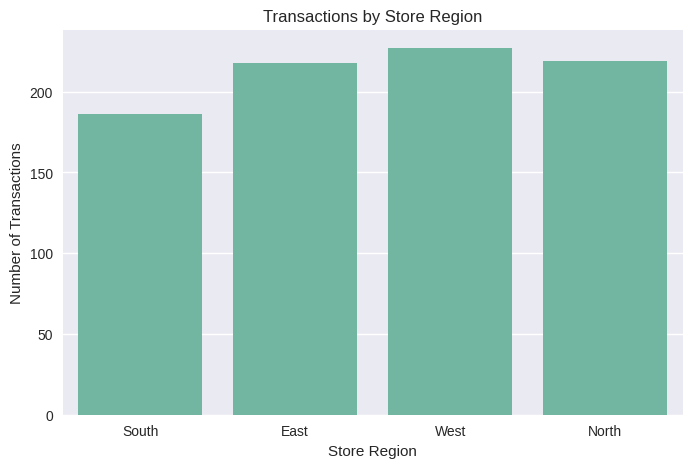

In [90]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="store_region"
)

plt.title("Transactions by Store Region")
plt.xlabel("Store Region")
plt.ylabel("Number of Transactions")

plt.show()


In [91]:
segment_revenue = (
    df.groupby("customer_segment")["order_value"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue


,order_value
customer_segment,
Wholesale,35069.29
Premium,21143.28
Regular,19999.33


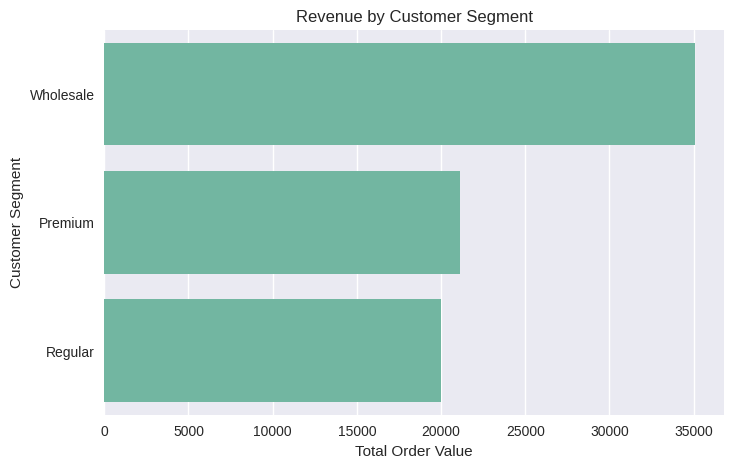

In [92]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_revenue.values,
    y=segment_revenue.index
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Total Order Value")
plt.ylabel("Customer Segment")

plt.show()


In [93]:
region_revenue = (
    df.groupby("store_region")["order_value"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue


,order_value
store_region,
West,28459.18
North,17853.39
East,17362.63
South,13765.25


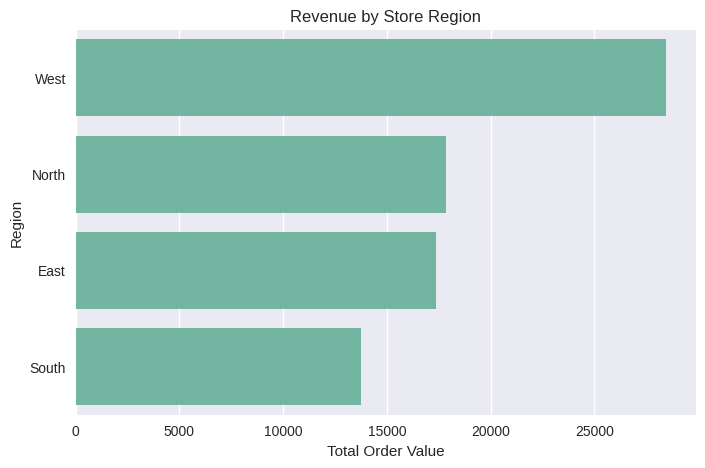

In [94]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_revenue.values,
    y=region_revenue.index
)

plt.title("Revenue by Store Region")
plt.xlabel("Total Order Value")
plt.ylabel("Region")

plt.show()


In [95]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()


,transaction_id,order_value
0,1,15.41
1,2,60.58
2,3,94.70
3,4,22.73
4,5,25.38


In [96]:
numeric_df = numeric_df.drop(columns=["transaction_id"])


In [97]:
correlation = numeric_df.corr()

correlation


,order_value
order_value,1.0


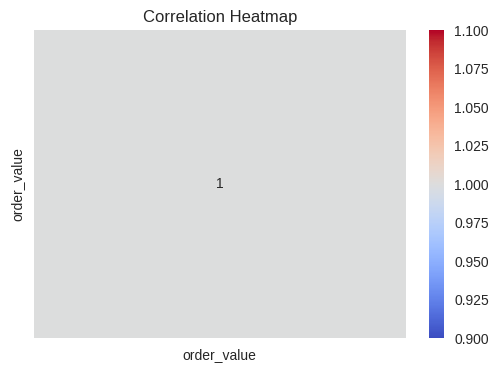

In [98]:
plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


In [99]:
avg_order_segment = (
    df.groupby("customer_segment")["order_value"]
    .mean()
    .sort_values(ascending=False)
)

avg_order_segment


,order_value
customer_segment,
Wholesale,115.359507
Premium,80.088182
Regular,74.903858


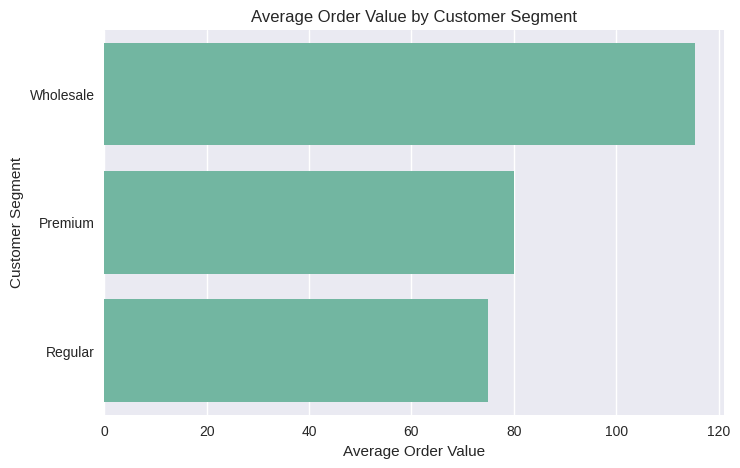

In [100]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_order_segment.values,
    y=avg_order_segment.index
)

plt.title("Average Order Value by Customer Segment")
plt.xlabel("Average Order Value")
plt.ylabel("Customer Segment")

plt.show()


## Conclusion and Business Recommendations

### Conclusion

The exploratory data analysis of the retail sales dataset helped identify important patterns in customer behaviour, revenue distribution, and purchasing trends. Monthly and quarterly sales analysis revealed variations in purchasing activity, while customer segment and regional analysis highlighted areas contributing the most business value.

The average order value analysis provided additional insight into customer spending behaviour, showing that different customer segments contribute differently to overall revenue performance.

### Business Recommendations

1. **Target high-value customer segments**
   
   Customer segments with higher average order values should be prioritised through personalised marketing campaigns, loyalty programmes, and premium offers to increase customer retention.

2. **Improve regional sales strategies**
   
   Regions generating higher revenue should receive better inventory planning and marketing support. Lower-performing regions should be analysed for opportunities to improve customer engagement.

3. **Use sales trends for better planning**
   
   Monthly and quarterly sales patterns should guide inventory management, staffing decisions, and promotional campaigns to prepare for periods of higher customer demand.

4. **Increase customer spending through targeted offers**
   
   Customers with lower average order values can be encouraged to spend more through bundle offers, discounts, and cross-selling strategies.

